# Storm Catalog Diagnostics

Generate the full set of **storm-motion diagnostic plots** from a *storm catalog*
(a folder of NetCDF storm events produced by RainyDay).

You provide the inputs and parameters through a **JSON config** (`configs/`), or
override them inline below. The exact same pipeline runs headless from the command line:

```bash
python run_diagnostics.py --config configs/testing_data.json
```

In [1]:
# Make the package importable and pick up code edits without a manual kernel restart.
import os, sys
root = os.getcwd()
while not os.path.isdir(os.path.join(root, "stormcatalog_analyzer")) and root != os.path.dirname(root):
    root = os.path.dirname(root)
os.chdir(root)
if root not in sys.path:
    sys.path.insert(0, root)
# drop any cached package modules so edits are re-read from disk on re-run
for _m in [m for m in list(sys.modules) if m.startswith("stormcatalog_analyzer")]:
    del sys.modules[_m]

from stormcatalog_analyzer.config import load_config
from stormcatalog_analyzer import pipeline
print("repo root:", root)

/opt/anaconda3/envs/storm-motion-analyzer/lib/python3.10/site-packages/mpu/string.py:16: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


repo root: /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer


## 1. Configuration — inputs & parameters

Load a config file, then optionally override any field inline. All paths resolve
relative to `project_root` (the repo root by default).

In [2]:
cfg = load_config("configs/testing_data.json")

# --- Optional inline overrides (edit to point at YOUR catalog) ---
cfg.io.max_events = 200 # limit the number of events to process (for testing)
# cfg.io.catalog_dir               = "testing_data/StormCatalog"
# cfg.io.transposition_domain_path = "testing_data/TranspositionDomain/Domain_58.shp"
# cfg.io.output_dir                = "testing_data"
# cfg.io.domain_name               = "Test Domain"
# cfg.tracking.morph_radius_cells       = 2       # storm-merging radius (cells)
# cfg.tracking.rainfall_threshold_mmhr  = 2     # rainfall threshold (mm/hr)
# cfg.selection.min_duration_hr         = 6       # drop storms shorter than this (hours)
# cfg.motion.intensity_window_hr        = 12      # window for the most-intense period (hours)
# cfg.motion.n_trajectories_plotted     = 100     # number of events on the trajectory map

cfg.validate()
cfg

Config(io=IOConfig(catalog_dir='testing_data/StormCatalog', transposition_domain_path='testing_data/TranspositionDomain/Domain_58.shp', control_area_path=None, grid_path=None, output_dir='testing_data', domain_name='Test Domain', max_events=200), tracking=TrackingConfig(rainfall_var_name='rain', morph_radius_cells=2, rainfall_threshold_mmhr=2, ellipse_fit_method='moments', overlap_ratio_threshold=0.2, dry_spell_hr=0), selection=SelectionConfig(min_duration_hr=6, min_area_fraction=0.05), motion=MotionConfig(intensity_window_hr=12, n_trajectories_plotted=100), figure=FigureConfig(font_size=0, dpi=300, smooth_factor=0.05, arrow_scale=1.0, arrow_width=0.005, head_width=2.0, head_length=1.5), direction_grid=DirectionGridConfig(n_sectors=4, cell_size_km=50.0, count_threshold=100, start_angle_deg=None), project_root='.')

## 2. Run the pipeline

`pipeline.run` performs three stages — **track** every event, **summarize** motion (direction/speed/trajectory per storm), and **generate** outputs — saving a per-storm **CSV** (`storm_properties_<domain>.csv`) and the diagnostic figures under `output_dir/<domain_name>/`.

**Direction convention.** Directions are reported as the direction of motion in **degrees counterclockwise from east** (0° = E, 90° = N, 180° = W, 270° = S), relative to **true** east/north. They are computed from geodesics on the WGS84 ellipsoid between centroid longitude/latitude, not from the EPSG:2163 grid, whose north differs from true north by the meridian convergence (about 5° over this Iowa domain). Speed, trajectory length, and angular variance are geodesic as well.

| Column | Meaning |
|---|---|
| `mean_direction_deg` | distance-weighted circular mean of the segment directions |
| `mean_direction_vector_deg` | unweighted circular mean of the segment directions |
| `endpoint_direction_deg` | direction from the first to the last centroid (not identical to the weighted mean) |
| `*_grid` columns | legacy EPSG:2163 grid-plane values, kept only for comparison |

In [3]:

out = pipeline.run(cfg)
summary = out["summary"]
print("per-storm CSV:", out["table"])
summary.storm_properties

The longest storm has a valid duration of 10 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2015-06-12T01:00:00.000000000 to 2015-06-12T10:00:00.000000000
Selected storm duration 10 hours
ok   IOWA_Domain.nc_storm_350_20150611.nc
The longest storm has a valid duration of 6 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2019-09-12T05:00:00.000000000 to 2019-09-12T10:00:00.000000000
Selected storm duration 6 hours
ok   IOWA_Domain.nc_storm_351_20190912.nc
The longest storm has a valid duration of 7 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2011-07-15T20:00:00.000000000 to 2011-07-16T02:00:00.000000000
Selected storm duration 7 hours
ok   IOWA_Domain.nc_storm_352_20110715.nc
The longest storm has a valid duration of 9 hours
The selected duration is longer than 0.1 of 24 hours
Selected storm starts from 2018-09-01T07:00:00.000000000 to 2018-09-01T15:00:00.000000000
Sele

/Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/stormcatalog_analyzer/plotting/diagnostics.py:200: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])
/Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/stormcatalog_analyzer/plotting/diagnostics.py:362: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.95])



Saved storm-properties table:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_properties_Test Domain.csv
Saved 3 figures:
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_trajectories_diagnostic_plot_Test Domain.png
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_direction_vector_plot_Test Domain.png
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_statistics_pairplot_Test Domain.png
per-storm CSV: /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/storm_properties_Test Domain.csv


,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,endpoint_direction_deg,angular_variance,...,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg,mean_direction_grid_deg,angular_variance_grid,mean_speed_grid_ms,trajectory_length_grid_km
0,IOWA_Domain.nc_storm_350_20150611.nc,350,2015-06-12 01:00:00,2015-06-12 10:00:00,10,14.252017,25.259721,5.421192,25.769744,0.340615,...,50.364334,68205.932444,410.458077,399.316362,170.265180,3.489199,30.120616,0.338290,14.243626,410.216440
1,IOWA_Domain.nc_storm_351_20190912.nc,351,2019-09-12 05:00:00,2019-09-12 10:00:00,6,11.200264,86.580125,68.619639,86.523739,0.450647,...,35.692192,43214.523474,161.283808,322.770710,96.550508,-19.598952,92.309782,0.450513,11.177728,160.959289
2,IOWA_Domain.nc_storm_352_20110715.nc,352,2011-07-15 20:00:00,2011-07-16 02:00:00,7,9.249768,324.919236,327.875496,325.346223,0.037733,...,115.367401,30653.727574,166.495825,177.073446,84.366016,25.536370,329.618544,0.037741,9.229719,166.134949
3,IOWA_Domain.nc_storm_353_20180901.nc,353,2018-09-01 07:00:00,2018-09-01 15:00:00,9,7.895431,21.323114,338.404413,20.989258,0.730549,...,48.359783,85885.691885,198.964857,371.233992,175.542568,25.679952,26.579086,0.729705,7.890155,198.831898
4,IOWA_Domain.nc_storm_354_20140603.nc,354,2014-06-04 00:00:00,2014-06-04 11:00:00,12,9.208895,336.592265,339.744217,337.434041,0.197853,...,100.624763,103004.413936,331.520206,319.859907,180.069732,-7.852704,341.344585,0.197402,9.189861,330.834981
5,IOWA_Domain.nc_storm_355_20180820.nc,355,2018-08-20 02:00:00,2018-08-20 14:00:00,13,8.002513,50.443910,53.183012,51.053026,0.287277,...,67.361008,70458.032605,316.899528,411.171483,148.372346,-50.297809,55.004018,0.288589,7.998606,316.744786
6,IOWA_Domain.nc_storm_356_20060910.nc,356,2006-09-11 02:00:00,2006-09-11 11:00:00,10,7.122960,22.360815,26.822411,22.977830,0.030935,...,51.808662,50638.066852,205.141251,259.860483,151.012236,16.700266,27.500899,0.030505,7.109660,204.758198
7,IOWA_Domain.nc_storm_357_20100605.nc,357,2010-06-05 05:00:00,2010-06-05 16:00:00,12,7.162879,13.397364,22.815143,13.686499,0.468778,...,106.963875,36177.742202,257.863648,233.667513,101.384261,-13.734301,18.120916,0.467603,7.148208,257.335488
8,IOWA_Domain.nc_storm_358_20190928.nc,358,2019-09-29 12:00:00,2019-09-29 21:00:00,10,8.999219,28.490784,50.707697,28.899050,0.207966,...,60.003036,50410.925267,259.177512,268.801959,123.071909,-1.805905,33.456996,0.205411,8.987841,258.849817
9,IOWA_Domain.nc_storm_359_20070807.nc,359,2007-08-08 06:00:00,2007-08-08 16:00:00,11,6.806543,182.916997,239.584469,183.204762,0.795816,...,58.302650,27960.941555,220.531987,210.682573,96.618929,5.648187,187.537033,0.796717,6.799688,220.309885


In [4]:
summary.storm_properties[summary.storm_properties["angular_variance"]<0.2]   # e.g. summary.storm_properties[summary.storm_properties["storm_name"].str.contains("112")].head()

,storm_event,storm_id,start_time,end_time,duration_hours,mean_speed_ms,mean_direction_deg,mean_direction_vector_deg,endpoint_direction_deg,angular_variance,...,total_rainfall_mm,storm_area_km2,trajectory_length_km,mean_major_axis_km,mean_minor_axis_km,mean_ellipse_angle_deg,mean_direction_grid_deg,angular_variance_grid,mean_speed_grid_ms,trajectory_length_grid_km
2,IOWA_Domain.nc_storm_352_20110715.nc,352,2011-07-15 20:00:00,2011-07-16 02:00:00,7,9.249768,324.919236,327.875496,325.346223,0.037733,...,115.367401,30653.727574,166.495825,177.073446,84.366016,25.536370,329.618544,0.037741,9.229719,166.134949
4,IOWA_Domain.nc_storm_354_20140603.nc,354,2014-06-04 00:00:00,2014-06-04 11:00:00,12,9.208895,336.592265,339.744217,337.434041,0.197853,...,100.624763,103004.413936,331.520206,319.859907,180.069732,-7.852704,341.344585,0.197402,9.189861,330.834981
6,IOWA_Domain.nc_storm_356_20060910.nc,356,2006-09-11 02:00:00,2006-09-11 11:00:00,10,7.122960,22.360815,26.822411,22.977830,0.030935,...,51.808662,50638.066852,205.141251,259.860483,151.012236,16.700266,27.500899,0.030505,7.109660,204.758198
10,IOWA_Domain.nc_storm_360_20020511.nc,360,2002-05-11 10:00:00,2002-05-11 18:00:00,9,12.737333,63.178839,61.128047,63.372928,0.142943,...,44.766331,160765.130644,320.980781,439.865867,254.374696,-43.328228,68.297660,0.140481,12.745228,321.179756
28,IOWA_Domain.nc_storm_378_20170721.nc,378,2017-07-21 13:00:00,2017-07-21 19:00:00,7,4.839869,344.495709,343.515718,344.708666,0.127551,...,37.051498,45668.898605,87.117634,311.126799,123.429046,-14.461154,349.615634,0.128534,4.827969,86.903436
29,IOWA_Domain.nc_storm_379_20150828.nc,379,2015-08-28 11:00:00,2015-08-28 23:00:00,13,5.988156,18.002774,12.093227,18.772019,0.040489,...,91.910378,70889.462396,237.130976,273.713642,138.404468,52.986353,22.857958,0.039836,5.975819,236.642420
32,IOWA_Domain.nc_storm_383_20150624.nc,383,2015-06-24 09:00:00,2015-06-24 17:00:00,9,11.404345,312.759407,316.937434,313.280801,0.093341,...,49.024982,39498.867331,287.389498,301.912009,102.942398,-17.753383,317.689769,0.094273,11.385352,286.910858
36,IOWA_Domain.nc_storm_387_20080724.nc,387,2008-07-24 11:00:00,2008-07-24 19:00:00,9,6.724585,314.980610,310.758369,315.305108,0.095683,...,55.064888,69132.488210,169.459538,289.351758,138.807987,-36.562554,319.380901,0.095907,6.712005,169.142519
37,IOWA_Domain.nc_storm_388_20170628.nc,388,2017-06-29 00:00:00,2017-06-29 10:00:00,11,10.534349,246.581189,267.262163,246.103205,0.180126,...,89.706345,44322.622923,341.312904,346.260164,112.090289,16.073869,251.694148,0.177241,10.541847,341.555857
39,IOWA_Domain.nc_storm_390_20070506.nc,390,2007-05-06 11:00:00,2007-05-06 23:00:00,13,7.566700,331.535929,336.509315,332.397285,0.162668,...,87.854546,79202.216646,299.641307,398.896426,129.266952,29.516881,336.232667,0.161383,7.552742,299.088572


## 3. Diagnostic figures

The full diagnostic set: storm-trajectory map + wind rose + direction/speed
distributions, the per-storm mean-direction vectors, and the storm-statistics pairplot.
The mean direction in the text boxes is in degrees counterclockwise from east (true north);
the wind roses are labelled with compass points and show the same directions.

storm_trajectories_diagnostic_plot_Test Domain.png


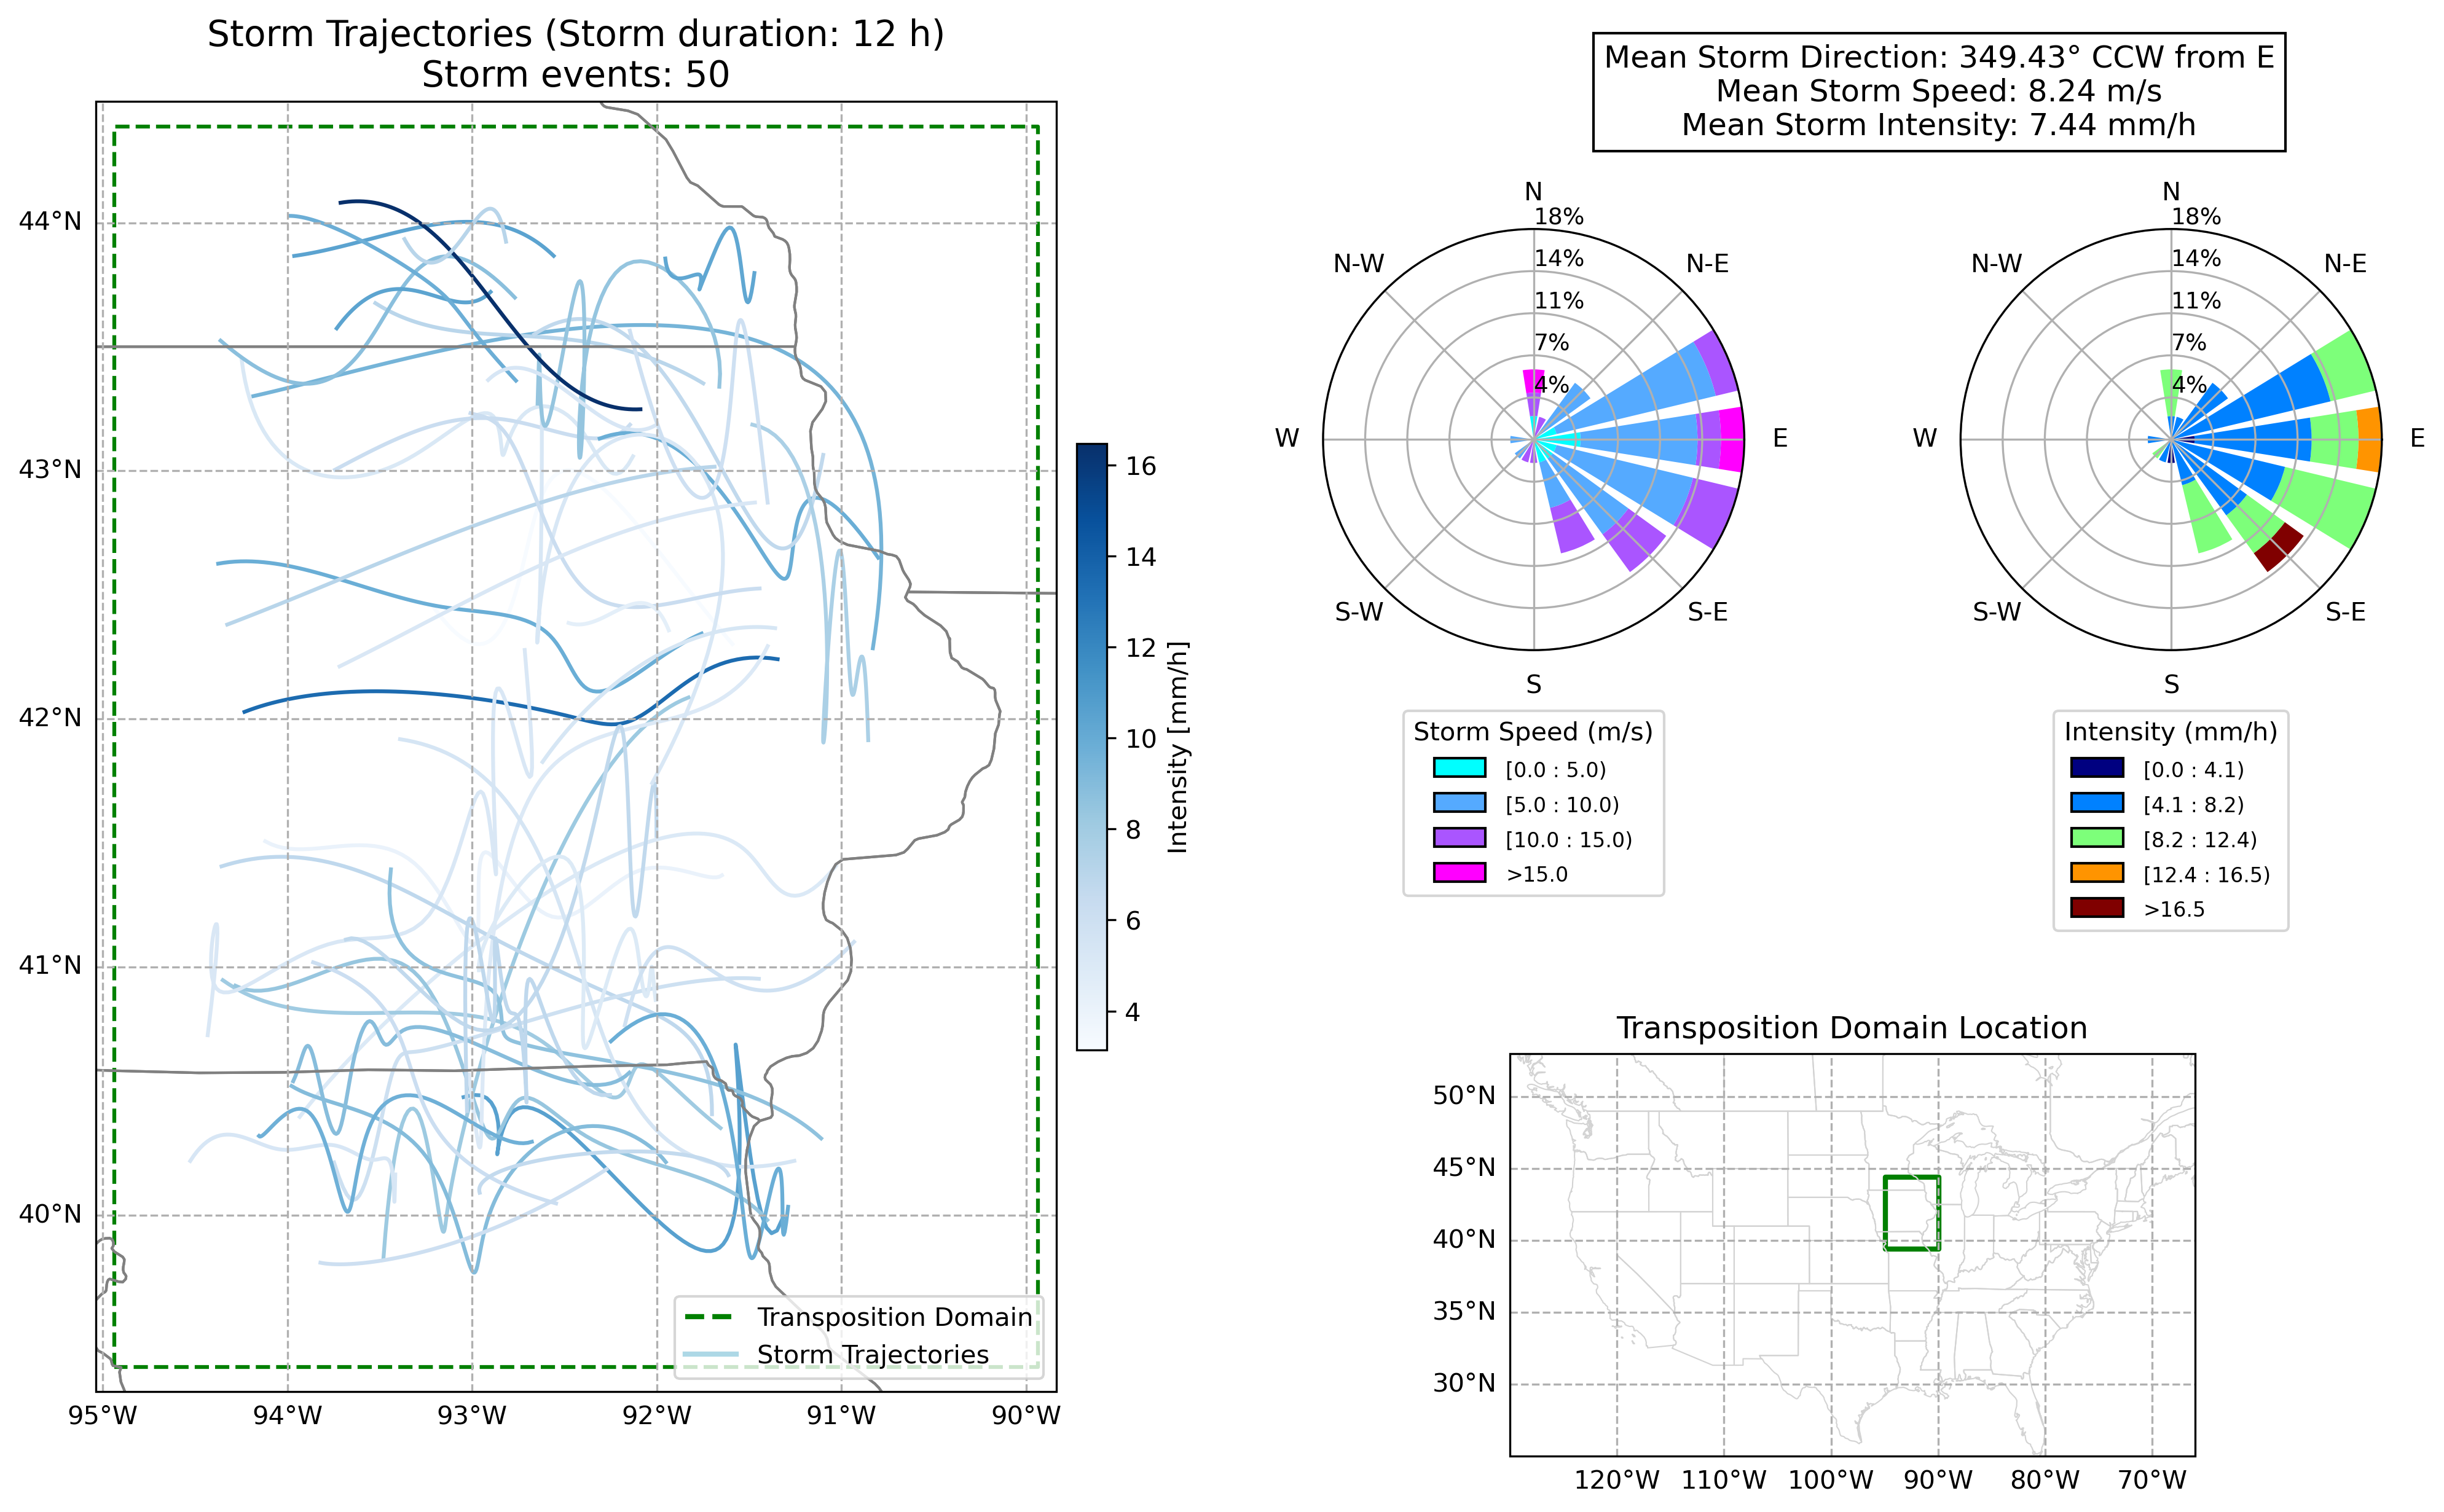

storm_direction_vector_plot_Test Domain.png


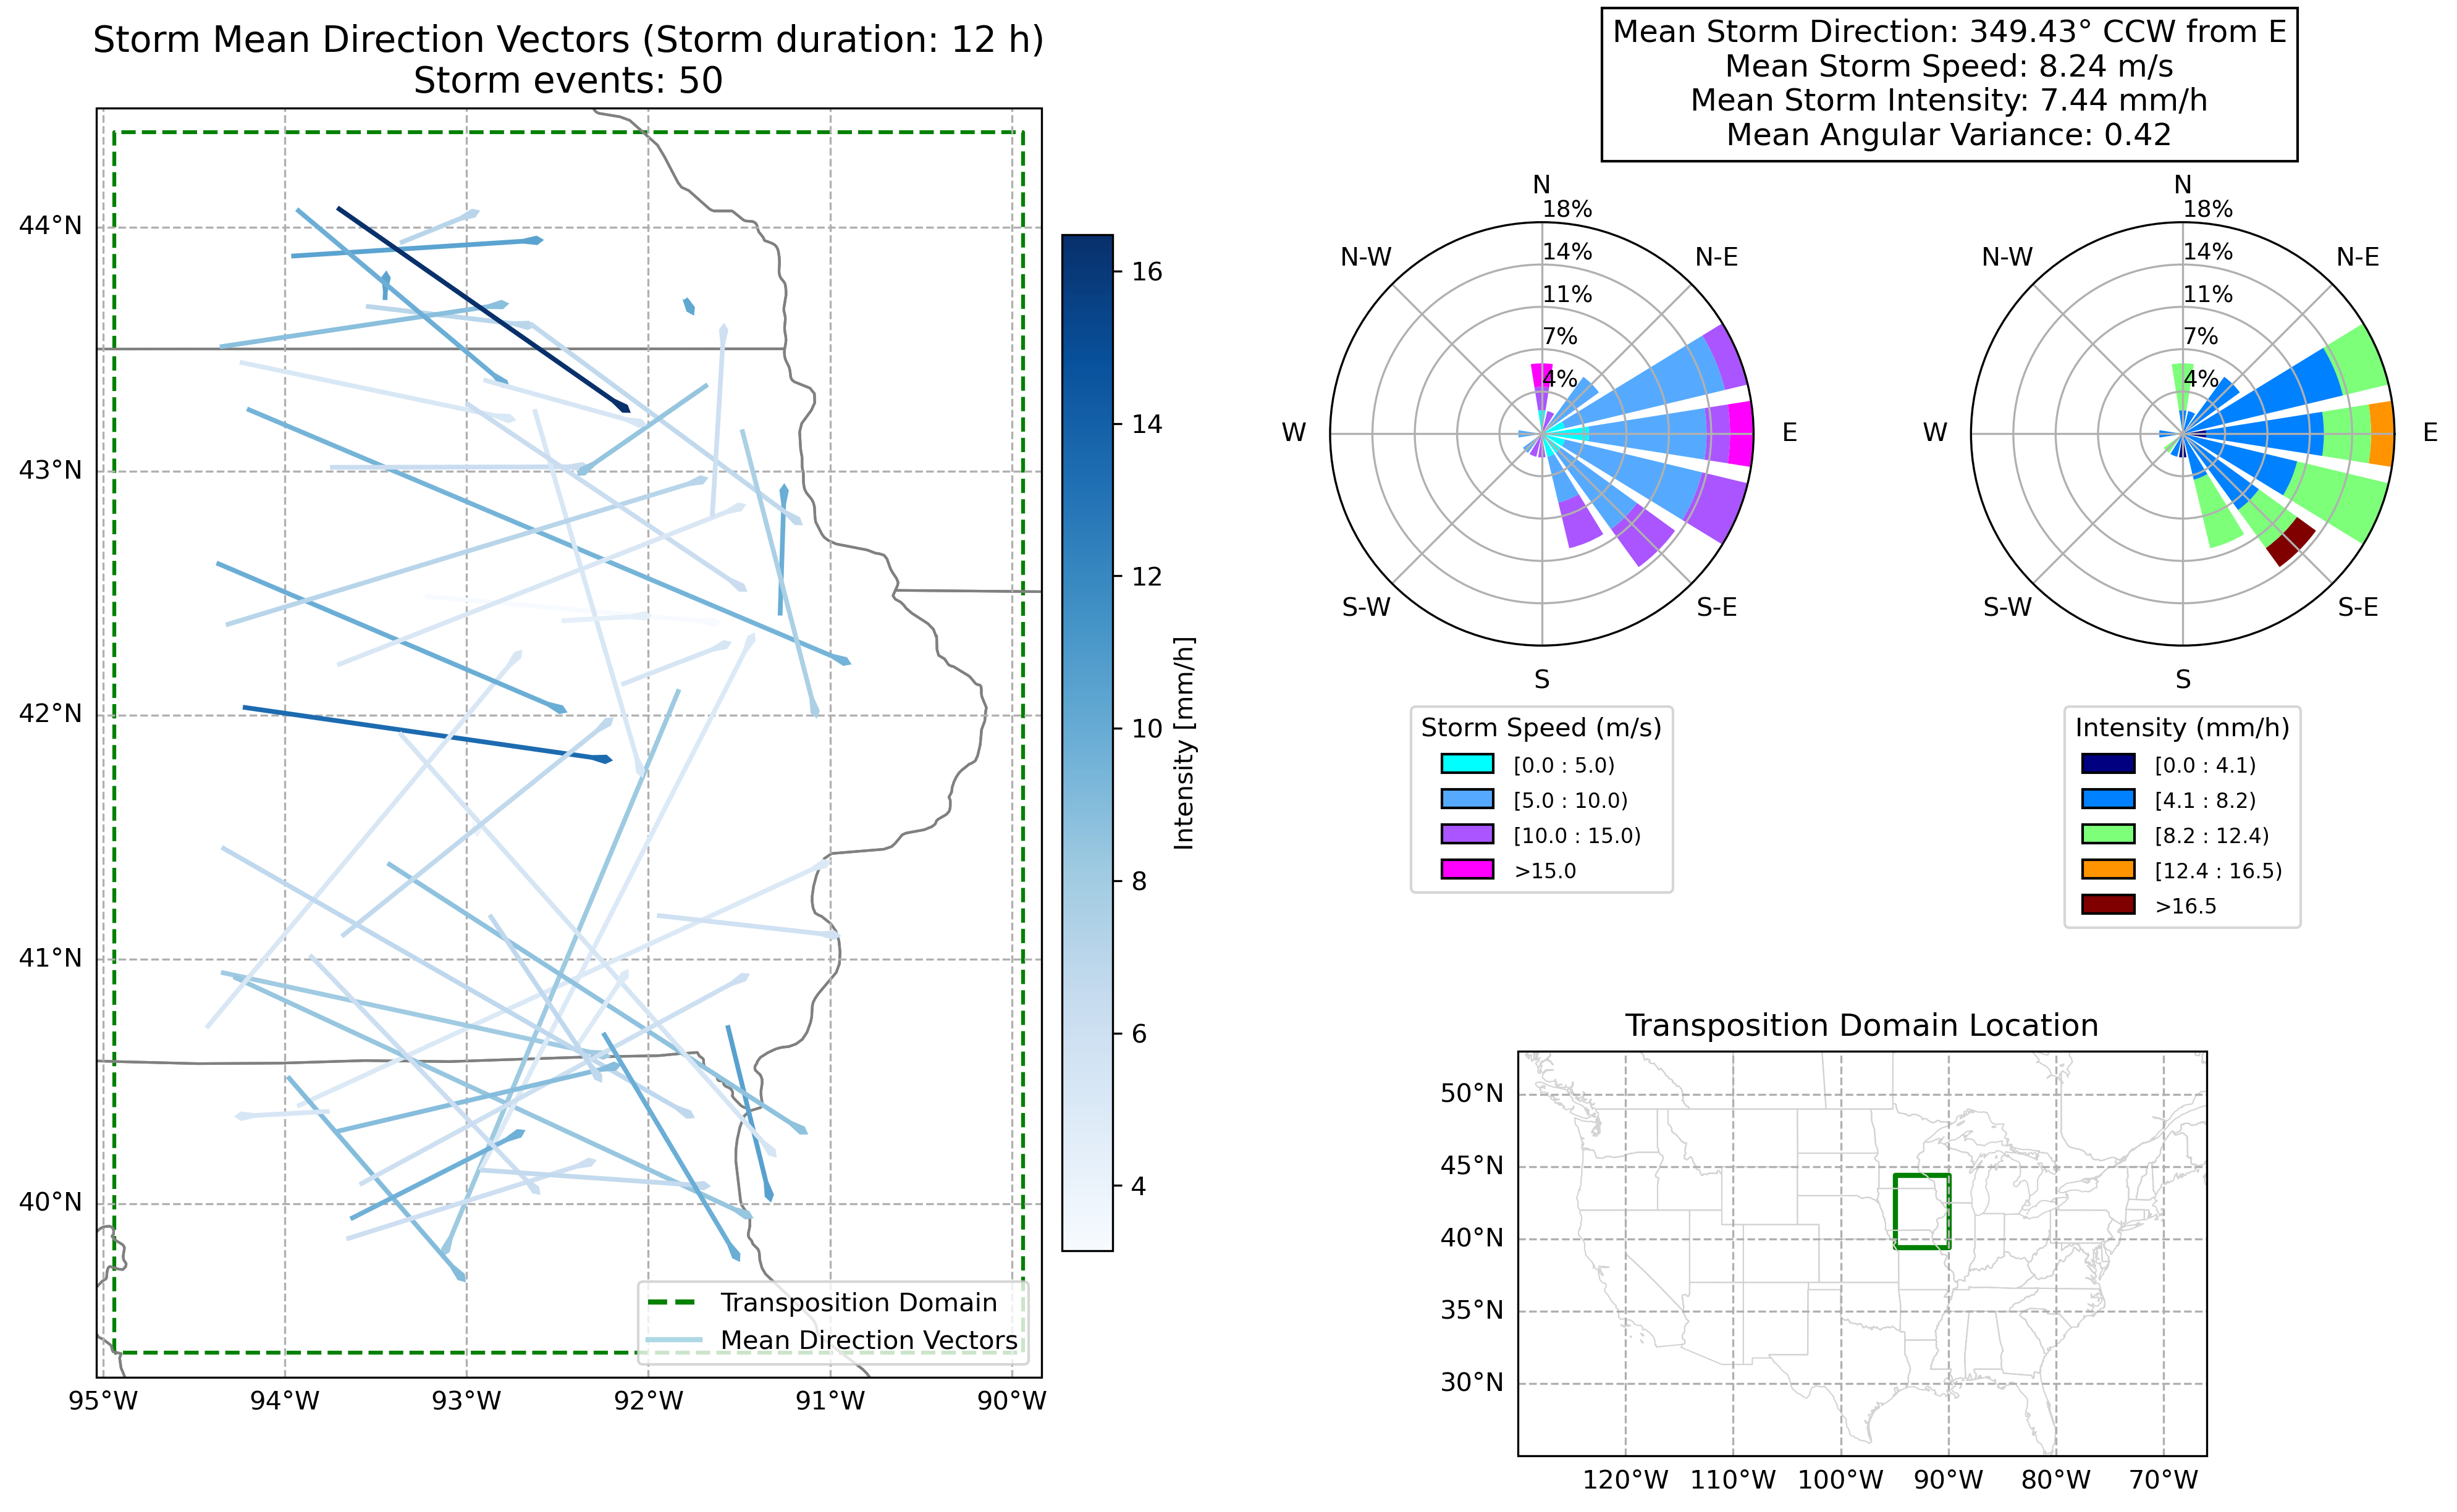

storm_statistics_pairplot_Test Domain.png


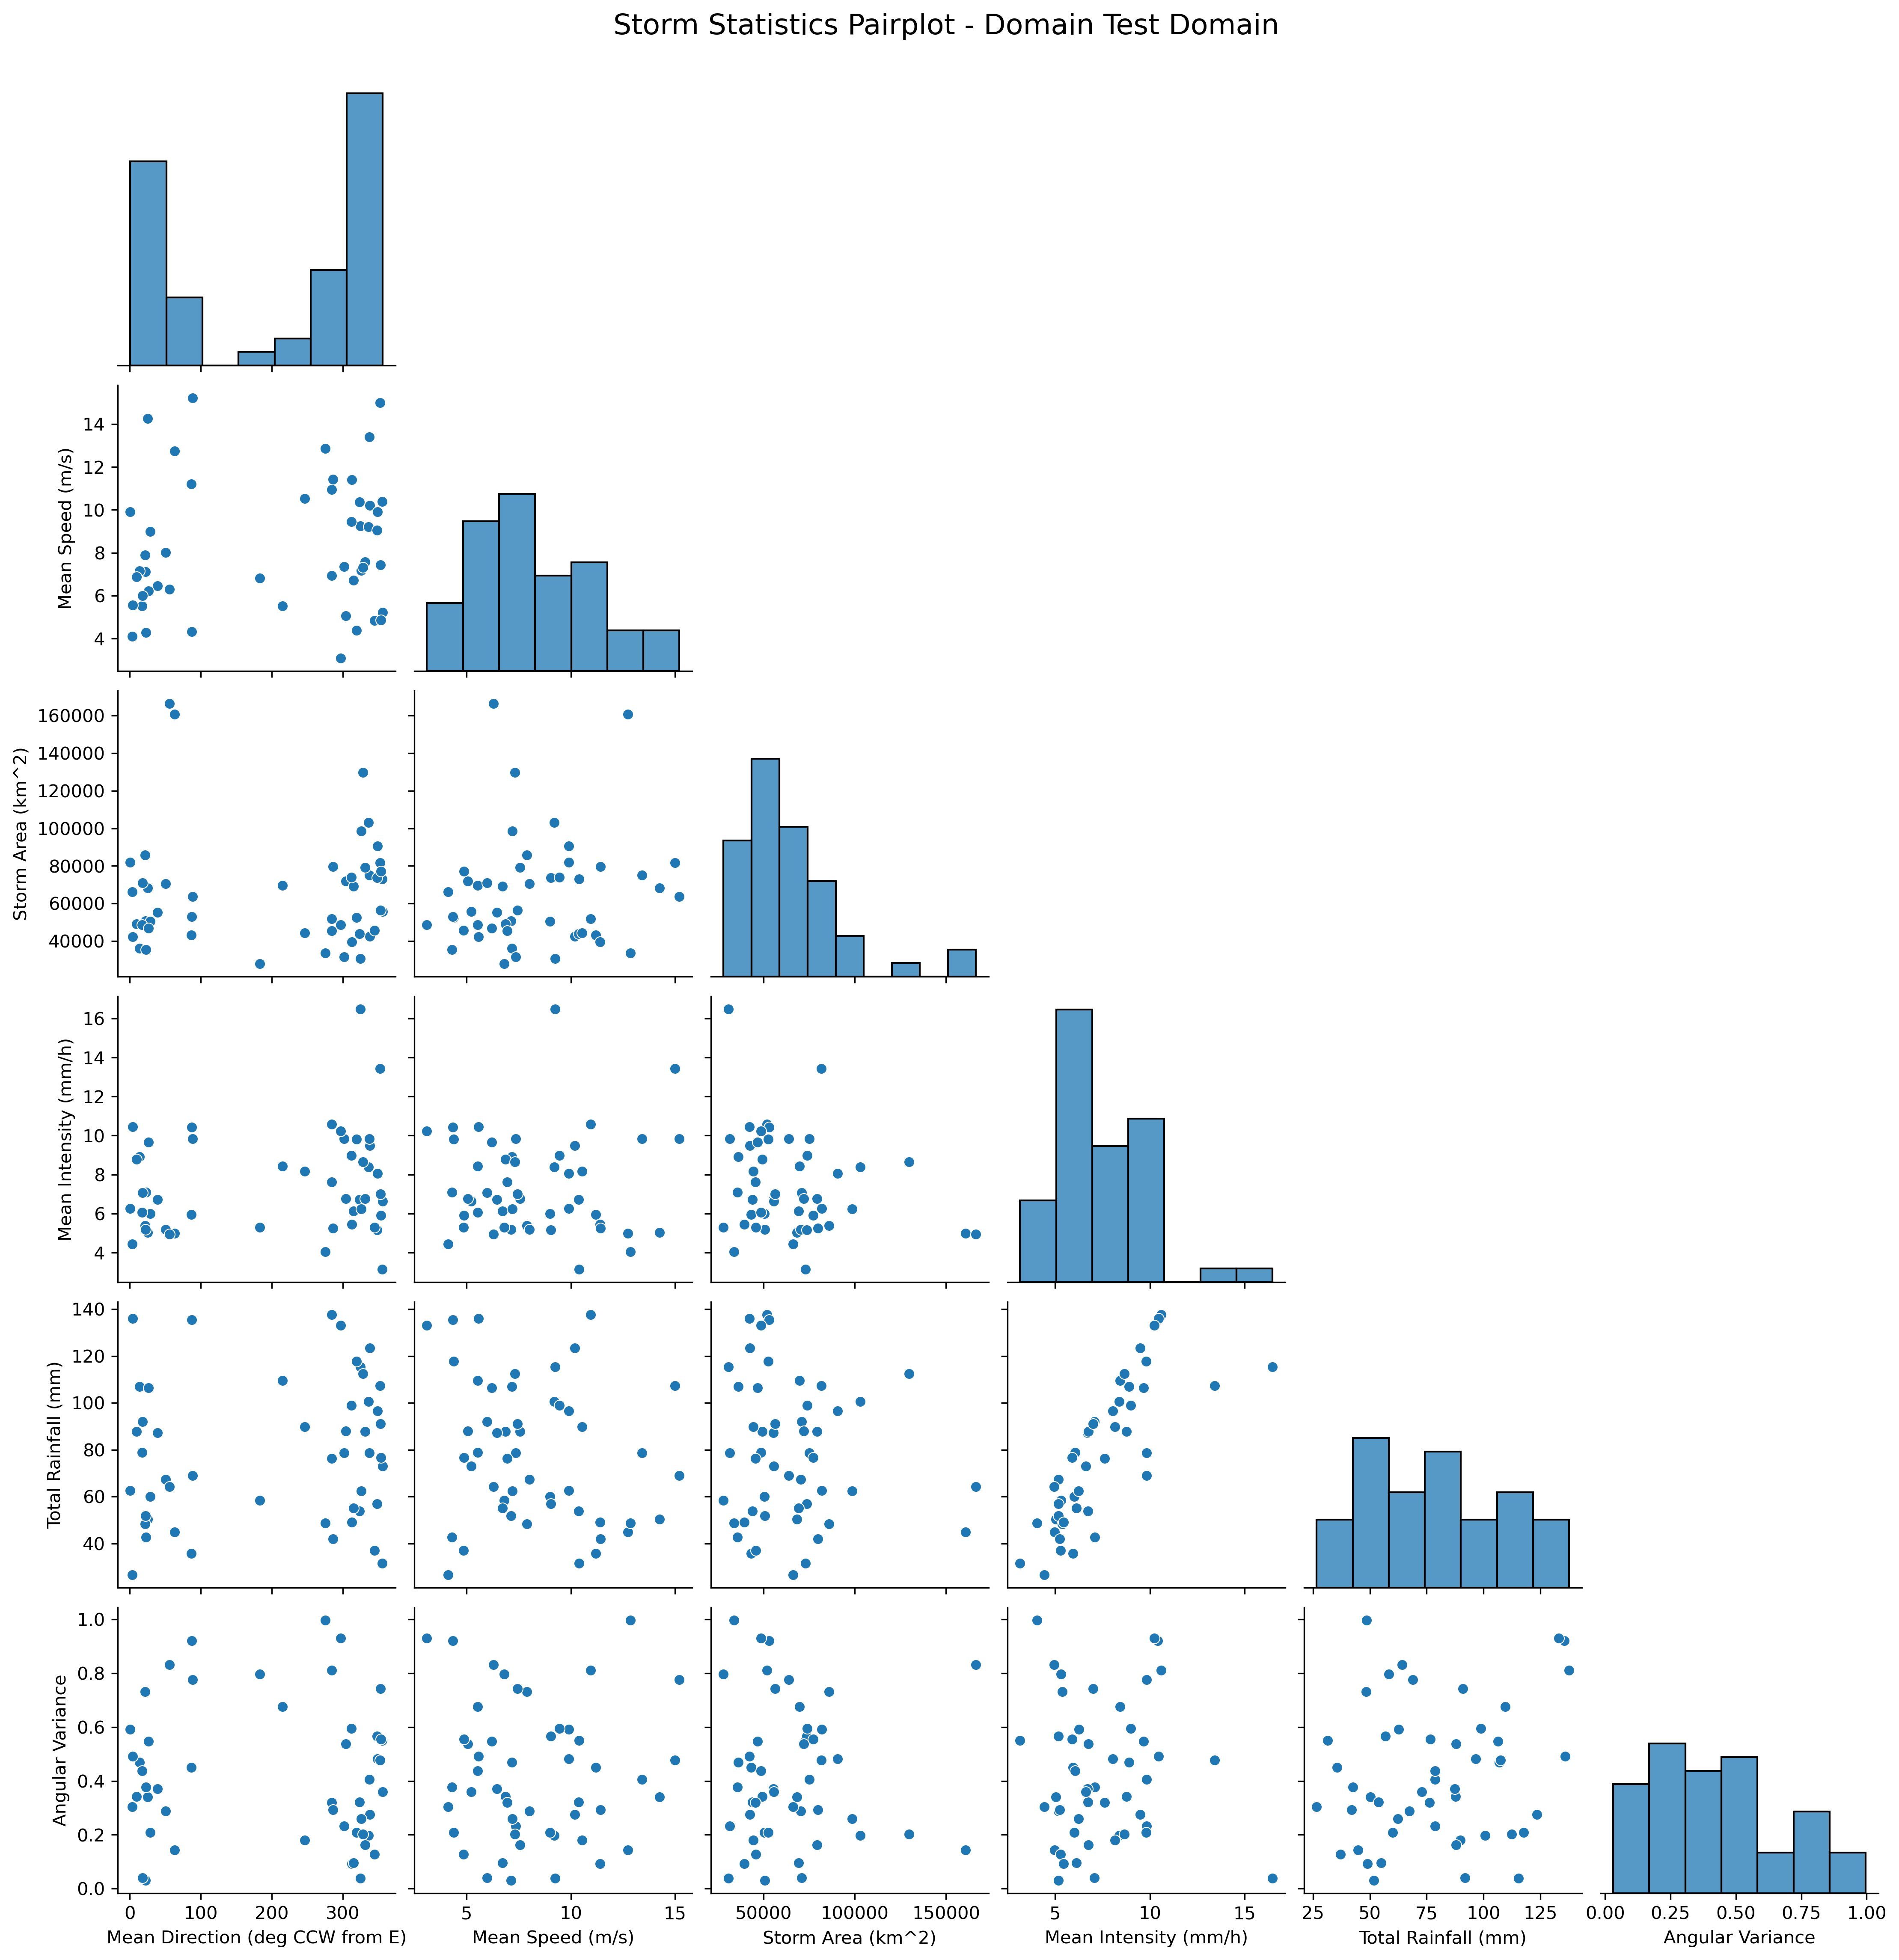

In [5]:
from IPython.display import Image, display
for fig_path in out["figures"]:
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

## 4. Individual per-event figures (all storms)

Generate the storm-track + time-step panels for **every** storm in the catalog
(2 figures per storm). This reuses the tracking results from step 2 (no re-tracking),
but is still slow for large catalogs — subsample with `cfg.io.max_events` if needed.
Figures are saved under `StormTrack/` and `StormTimeSteps/`.


In [6]:
event_figs = pipeline.generate_all_event_diagnostics(cfg, out["results"], summary)
print(f"saved {len(event_figs)} per-event figures")

  per-event figures: 25/50 storms
  per-event figures: 50/50 storms
Saved 100 per-event figures for 50 storms under
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTrack
  /Users/gjperezm/Library/CloudStorage/OneDrive-OklahomaAandMSystem/Academia/Codes/storm-motion-analyzer/testing_data/Test Domain/StormTimeSteps
saved 100 per-event figures


## 5. Storm-motion direction probability (grid diagnostic)

Build a storm-motion grid per storm, aggregate them into a per-cell **direction-
probability field** (four quadrants I–IV of the true-north direction, counterclockwise from east;
with `start_angle_deg = -45`, sector I is centred on east, II on north, III on west, IV on south), and render the 4-panel summary:
(a) total directional counts, (b) transposition-domain location, (c) direction-
probability fields, (d) direction regions. Panel (b)'s grid index labels require the
CONUS reference grid (`cfg.io.grid_path`); they are skipped when it is not set.

Uses every retained storm — subsample with `cfg.io.max_events` for a quick look.


Built 50 storm-motion grids (20 km cells); 4 sectors (90 deg each).


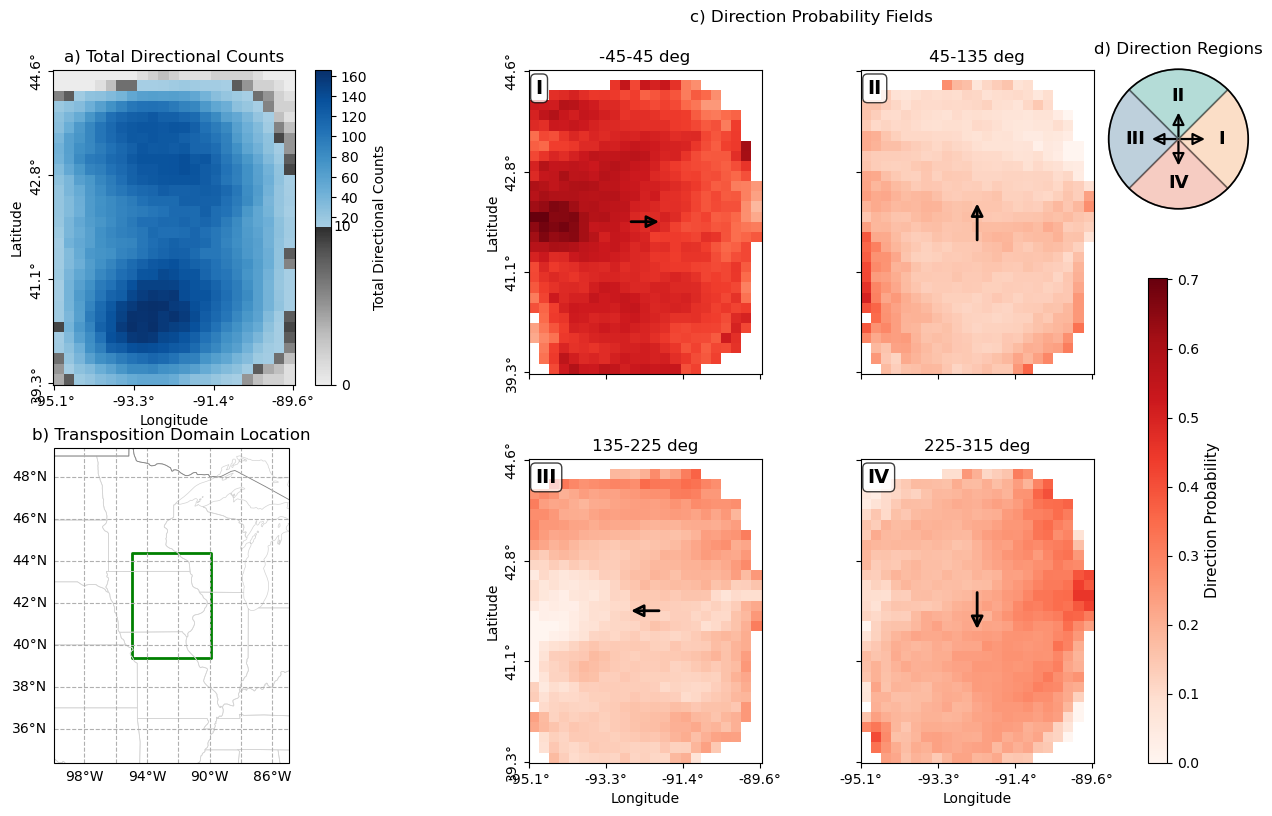

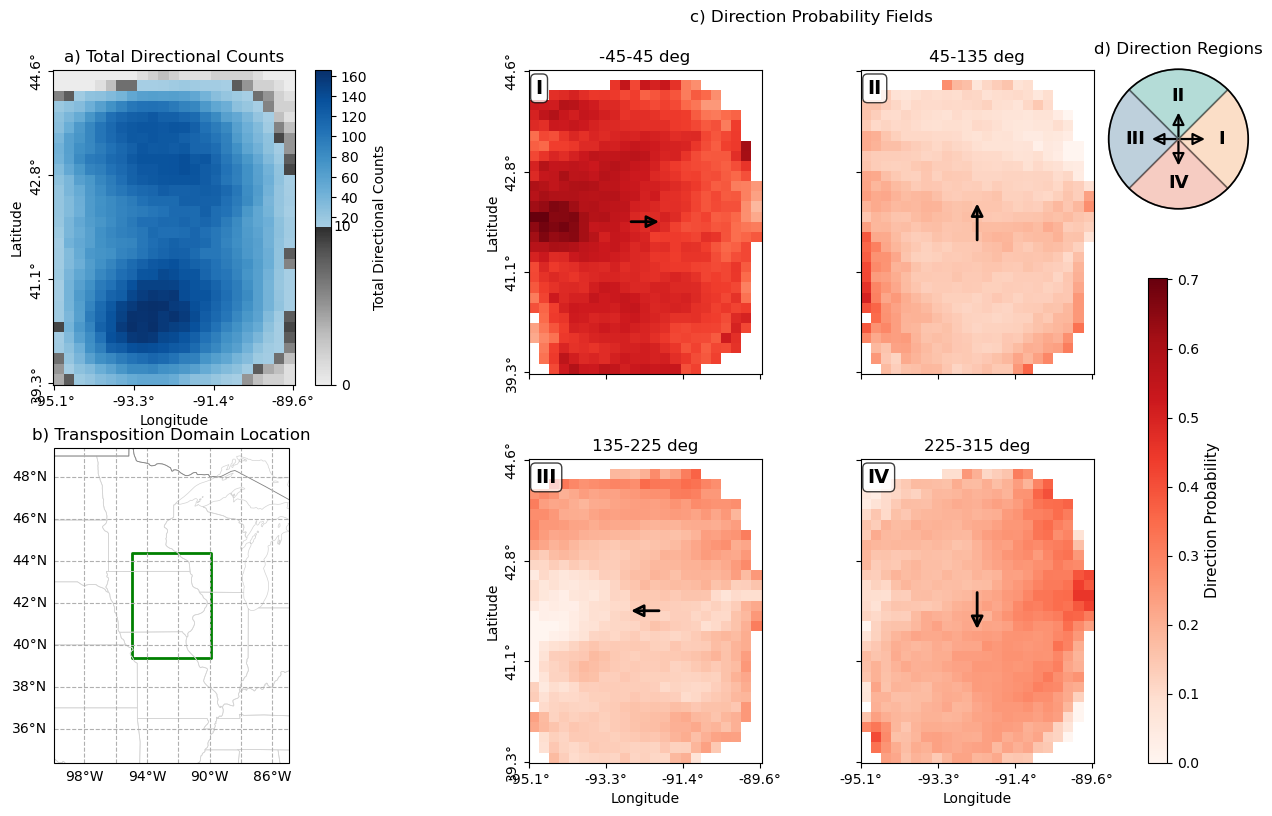

In [7]:
from stormcatalog_analyzer.plotting.motion_grid import plot_direction_probability_summary
from stormcatalog_analyzer import io as scio

# Number of sectors, grid resolution, etc. come from cfg.direction_grid
# (edit configs/testing_data.json -> "direction_grid": {"n_sectors": 8, ...})
cfg.direction_grid.n_sectors = 4
cfg.direction_grid.cell_size_km = 20
cfg.direction_grid.start_angle_deg = -45
cfg.direction_grid.count_threshold = 10
  # limit number of events to process (for testing)
prob_field = pipeline.build_direction_probability_field(out["results"], cfg)
transposition_domain = scio.load_vector(cfg.transposition_domain_path)
grid = scio.load_vector(cfg.grid_path)   # CONUS 5x5 reference grid (optional)

plot_direction_probability_summary(
    prob_field, transposition_domain, grid,
    count_threshold=cfg.direction_grid.count_threshold,
)